# Notebook 4: Time Intelligence
## Overview
This notebook analyzes when road accidents occur by examining trends across years, months, weekdays, and hours. Understanding temporal patterns helps identify peak accident periods and supports better traffic management and road safety planning.

## Objectives
- Analyze accident trends over time.
- Identify peak accident months and weekdays.
- Study hourly accident patterns.
- Generate time-based business insights.

## Business Questions
1. How have road accidents changed over the years?
2. Which months record the highest number of accidents?
3. Which day of the week experiences the most accidents?
4. During which hours do most accidents occur?
5. Which time period records the highest number of accidents?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_excel("indian_roads_dataset21.xlsx")

## Analysis 1
### Business Question
How have road accidents changed over the years?

In [ ]:
df["year"] = df["date"].dt.year
yearly_accidents = (df.groupby("year").size().reset_index(name="Accidents"))
yearly_accidents

,year,Accidents
0,2022,6117
1,2023,6088
2,2024,6061
3,2025,1734


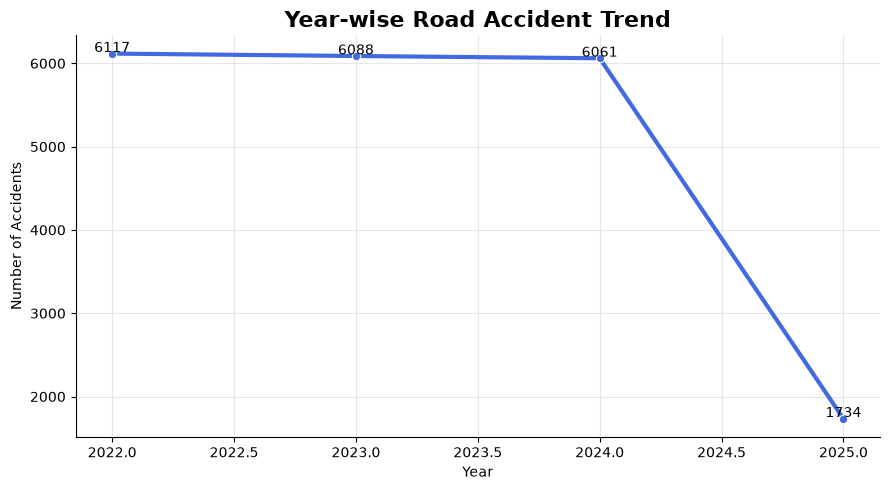

In [12]:
plt.figure(figsize=(9,5))

ax = sns.lineplot(
    data=yearly_accidents,
    x="year",
    y="Accidents",
    marker="o",
    linewidth=3,
    color="royalblue"
)

plt.title(
    "Year-wise Road Accident Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Accidents")

plt.grid(alpha=0.3)

for x, y in zip(
    yearly_accidents["year"],
    yearly_accidents["Accidents"]
):
    plt.text(
        x,
        y + 20,
        y,
        ha="center",
        fontsize=10
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Road accident counts vary across different years.
- Some years record noticeably higher accident frequencies.
- The yearly trend highlights changes in accident occurrence over time. -->

<!-- ### Business Insight
Year-wise analysis helps evaluate long-term accident trends and can support the assessment of road safety initiatives implemented over different years.

## Analysis 2
### Business Question
Which months record the highest number of road accidents?

In [16]:
df["month"] = df["date"].dt.month_name()

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_accidents = (df.groupby("month").size().reindex(month_order).reset_index(name="Accidents"))
monthly_accidents

,month,Accidents
0,January,2044
1,February,1865
2,March,2043
3,April,1763
4,May,1593
5,June,1512
6,July,1543
7,August,1588
8,September,1475
9,October,1516


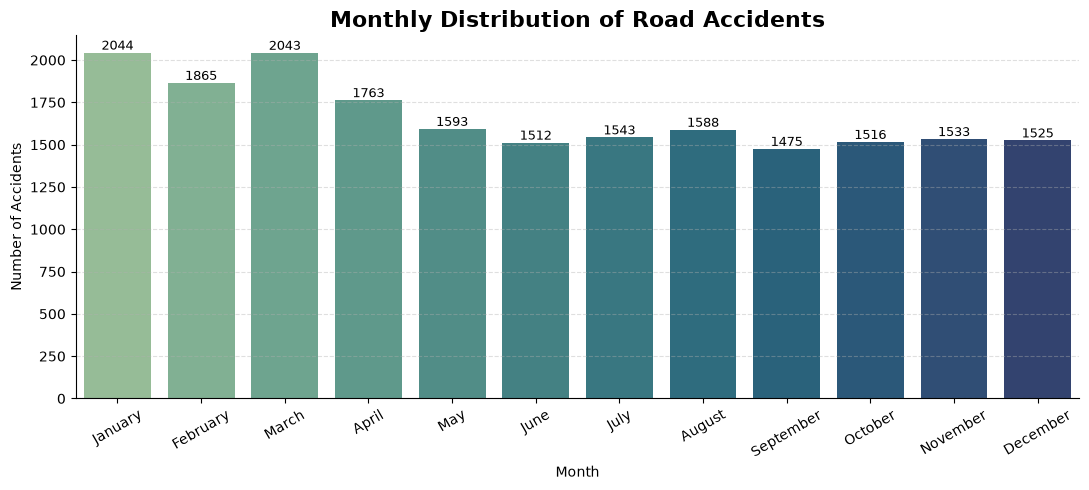

In [17]:
plt.figure(figsize=(11,5))

ax = sns.barplot(
    data=monthly_accidents,
    x="month",
    y="Accidents",
    hue="month",
    palette="crest",
    legend=False
)

plt.title(
    "Monthly Distribution of Road Accidents",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=30)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Accident frequency varies across different months.
- Certain months experience noticeably higher accident counts than others.
- Monthly trends indicate seasonal variations in road accidents. -->

<!-- ### Business Insight
Understanding monthly accident trends helps authorities schedule awareness campaigns, strengthen traffic monitoring, and allocate resources during high-risk months.

## Analysis 3
### Business Question
Which day of the week experiences the highest number of road accidents?

In [18]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
weekday_accidents = (df.groupby("day_of_week").size().reindex(day_order).reset_index(name="Accidents"))
weekday_accidents

,day_of_week,Accidents
0,Monday,2966
1,Tuesday,2871
2,Wednesday,2726
3,Thursday,2835
4,Friday,2879
5,Saturday,2867
6,Sunday,2856


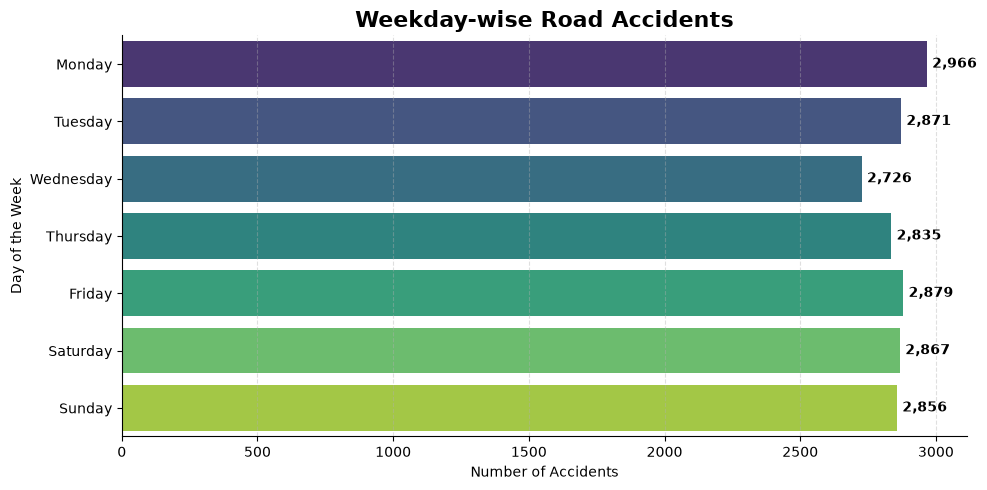

In [19]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=weekday_accidents,
    x="Accidents",
    y="day_of_week",
    hue="day_of_week",
    palette="viridis",
    legend=False
)

plt.title(
    "Weekday-wise Road Accidents",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Day of the Week")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(weekday_accidents["Accidents"]):
    ax.text(
        v + 20,
        i,
        f"{v:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Accident frequency varies across different days of the week.
- Certain weekdays consistently record more accidents than others.
- The distribution indicates that accident occurrence is influenced by weekly travel patterns. -->

<!-- ### Business Insight
Identifying high-risk weekdays enables traffic authorities to increase patrols, improve monitoring, and strengthen road safety measures during the busiest periods.

## Analysis 4
### Business Question
During which hours do most road accidents occur?

In [ ]:
df["hour"] = pd.to_datetime(df["time"],format="%H:%M:%S").dt.hour
hourly_accidents = (df.groupby("hour").size().reset_index(name="Accidents"))
hourly_accidents

,hour,Accidents
0,0,840
1,1,859
2,2,888
3,3,824
4,4,805
5,5,827
6,6,856
7,7,786
8,8,849
9,9,786


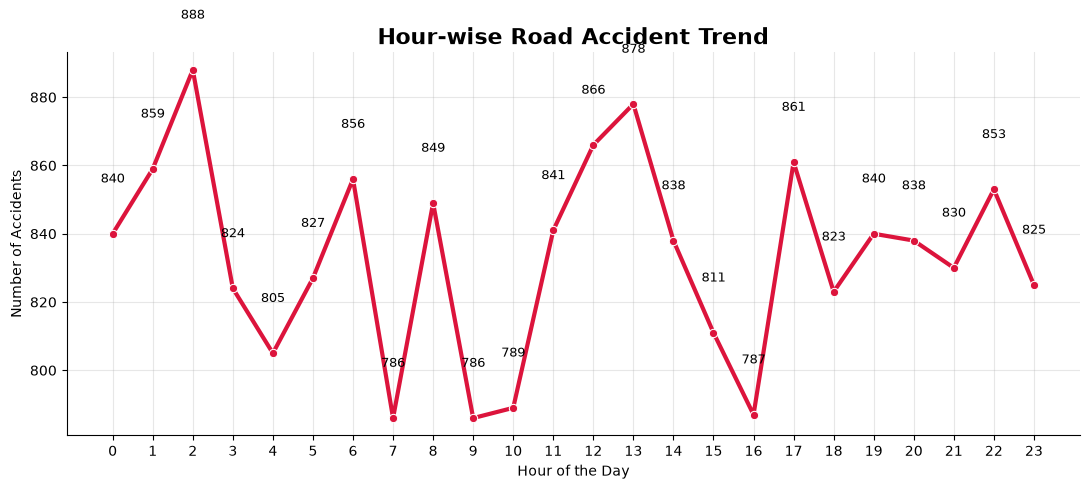

In [21]:
plt.figure(figsize=(11,5))

ax = sns.lineplot(
    data=hourly_accidents,
    x="hour",
    y="Accidents",
    marker="o",
    linewidth=3,
    color="crimson"
)

plt.title(
    "Hour-wise Road Accident Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour of the Day")
plt.ylabel("Number of Accidents")

plt.xticks(range(0, 24))

plt.grid(alpha=0.3)

for x, y in zip(
    hourly_accidents["hour"],
    hourly_accidents["Accidents"]
):
    plt.text(
        x,
        y + 15,
        y,
        ha="center",
        fontsize=9
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Road accidents are concentrated during specific hours of the day.
- Accident frequency increases during peak travel hours.
- Late-night and early-morning hours generally record fewer accidents. -->

<!-- ### Business Insight
Understanding hourly accident patterns helps authorities deploy traffic personnel, improve signal management, and strengthen emergency response during high-risk hours.

## Analysis 5
### Business Question
Which time period records the highest number of road accidents?

In [22]:
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"  
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"
df["time_period"] = df["hour"].apply(get_time_period)

period_accidents = (df.groupby("time_period").size().reindex(["Morning", "Afternoon", "Evening", "Night"]).reset_index(name="Accidents"))
period_accidents

,time_period,Accidents
0,Morning,5734
1,Afternoon,4180
2,Evening,3362
3,Night,6724


In [23]:
fig = px.pie(
    period_accidents,
    names="time_period",
    values="Accidents",
    hole=0.5,
    title="Road Accidents by Time Period",
    color_discrete_sequence=px.colors.sequential.Blues_r
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Observation
- Road accidents are not evenly distributed throughout the day.
- One time period contributes the highest proportion of accidents.
- Peak traffic hours are associated with increased accident frequency. -->

### Business Insight
Identifying high-risk time periods enables traffic authorities to deploy personnel efficiently, improve traffic control, and strengthen emergency response during peak accident hours.

This notebook analyzed the temporal distribution of road accidents across multiple time dimensions.
Key findings include:
- Examined yearly accident trends.
- Identified months with the highest accident frequency.
- Compared accident occurrence across weekdays.
- Analyzed hourly accident patterns.
- Determined the time period contributing the highest number of accidents.

Time-based analysis revealed that road accidents follow clear temporal patterns rather than occurring uniformly throughout the year. Certain months, weekdays, hours, and time periods consistently experience higher accident frequencies.
These insights can help traffic authorities optimize patrol schedules, improve emergency response planning, and implement targeted road safety campaigns during high-risk periods.